# Task 2: Dataset Sampling Strategy

This notebook supports Task 2 of the TechTrack case analysis. It profiles the full TechTrack logistics dataset, compares candidate 5,000-image sampling strategies, validates the selected subset against the full dataset, and generates the final Task 2 figures used in `CASE_ANALYSIS.md`.

The goal of this task is not to evaluate model accuracy. The goal is to design a representative working subset of the dataset for later compute-heavy analysis tasks while preserving the important structure of the original data.

## Methodology

The full TechTrack logistics dataset contains 9,525 images, 36,721 labeled objects, and 20 object classes. The assignment requires a minimum working subset of 5,000 images.

I evaluated three candidate sampling strategies:

1. `random_5000`: simple random sampling.
2. `density_stratified_5000`: sampling stratified by object-count density buckets.
3. `rare_aware_density_stratified_5000`: density-stratified sampling with rare-class retention safeguards.

The selected sample is validated across four dimensions:

- **Class distribution**: the object-class mix should remain close to the full dataset.
- **Rare-class coverage**: low-frequency classes should not be accidentally weakened.
- **Object-density distribution**: sparse, medium-density, and dense images should be preserved.
- **Crowding / overlap distribution**: because later NMS analysis is sensitive to overlapping boxes, the sample should preserve ground-truth box-crowding patterns.

The final selected sample is `rare_aware_density_stratified_5000`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        expected = candidate / "analysis" / "outputs" / "task2_selected_sample_index.csv"
        if expected.exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing analysis/outputs/task2_selected_sample_index.csv")

ROOT = find_repo_root(Path.cwd())
OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

dataset_index = pd.read_csv(OUT / "task2_dataset_index.csv")
full_summary = pd.read_csv(OUT / "task2_full_dataset_summary.csv")
class_enriched = pd.read_csv(OUT / "task2_class_distribution_full_enriched.csv")
top10_classes = pd.read_csv(OUT / "task2_top10_classes_by_object_count.csv")
bottom10_classes = pd.read_csv(OUT / "task2_bottom10_classes_by_object_count.csv")
density_full = pd.read_csv(OUT / "task2_density_bucket_distribution_full.csv")
dense_counts = pd.read_csv(OUT / "task2_dense_image_counts_full.csv")

candidate_quality = pd.read_csv(OUT / "task2_candidate_sample_quality.csv")
selected_sample = pd.read_csv(OUT / "task2_selected_sample_index.csv")
sample_summary = pd.read_csv(OUT / "task2_full_vs_selected_sample_summary.csv")
class_compare = pd.read_csv(OUT / "task2_full_vs_selected_class_distribution.csv")
rare_coverage = pd.read_csv(OUT / "task2_selected_rare_class_coverage.csv")
density_compare = pd.read_csv(OUT / "task2_full_vs_selected_density_distribution.csv")

overlap_summary = pd.read_csv(OUT / "task2_full_vs_selected_overlap_summary.csv")
crowding_compare = pd.read_csv(OUT / "task2_full_vs_selected_crowding_distribution.csv")

ROOT, OUT, FIG

(PosixPath('/home/armin/code/techtrack-arminrahbar'),
 PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/outputs'),
 PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures'))

## Table 1: Full Dataset Summary

This table summarizes the full TechTrack logistics dataset before sampling. It establishes the baseline distribution that the 5,000-image subset should preserve.

In [2]:
full_summary_display = full_summary.copy()

full_summary_display = full_summary_display.rename(columns={
    "dataset": "Dataset",
    "images": "Images",
    "total_objects": "Total Objects",
    "images_with_zero_objects": "Zero-Object Images",
    "mean_objects_per_image": "Mean Objects/Image",
    "median_objects_per_image": "Median Objects/Image",
    "max_objects_per_image": "Max Objects/Image",
    "images_ge_5_objects": "Images >=5 Objects",
    "images_ge_10_objects": "Images >=10 Objects",
    "images_ge_15_objects": "Images >=15 Objects",
    "images_ge_20_objects": "Images >=20 Objects",
})

full_summary_display

,Dataset,Images,Total Objects,Zero-Object Images,Mean Objects/Image,Median Objects/Image,Max Objects/Image,Images >=5 Objects,Images >=10 Objects,Images >=15 Objects,Images >=20 Objects
0,full_dataset,9525,36721,0,3.855,1.0,224,1780,881,517,304


**Interpretation.** The full dataset contains 9,525 images and 36,721 labeled objects. The median image has only one object, but the maximum image contains 224 objects. This means the dataset is mostly sparse but has a meaningful dense-scene tail. A valid sampling strategy should not only preserve class balance; it should also preserve dense multi-object scenes because those scenes are important for detection and later NMS analysis.

## Table 2: Full Dataset Class Distribution

This table shows class imbalance in the full dataset. It motivates rare-class protection in the sampling strategy.

In [3]:
class_distribution_display = class_enriched.copy()

for col in ["object_share_pct", "image_share_pct"]:
    class_distribution_display[col] = class_distribution_display[col].round(4)

class_distribution_display = class_distribution_display.rename(columns={
    "class_id": "Class ID",
    "class_name": "Class",
    "object_count": "Object Count",
    "image_count": "Image Count",
    "object_share_pct": "Object Share (%)",
    "image_share_pct": "Image Share (%)",
})

class_distribution_display.sort_values("Object Count", ascending=False)

,Class ID,Class,Object Count,Image Count,Object Share (%),Image Share (%)
19,19,wood pallet,9330,689,25.4078,7.2336
10,10,person,6368,1933,17.3416,20.2940
2,2,cardboard box,4995,443,13.6026,4.6509
3,3,fire,2793,1133,7.6060,11.8950
7,7,helmet,2170,631,5.9094,6.6247
14,14,smoke,1495,975,4.0712,10.2362
1,1,car,1379,1000,3.7553,10.4987
13,13,safety vest,1260,479,3.4313,5.0289
16,16,traffic light,1193,866,3.2488,9.0919
4,4,forklift,1103,949,3.0037,9.9633


**Interpretation.** The dataset is strongly imbalanced. Wood pallet, person, cardboard box, fire, and helmet account for a large share of labeled objects, while classes such as gloves, ladder, barcode, freight container, license plate, and QR code are much less frequent. This imbalance makes pure random sampling risky because rare classes may be underrepresented in a 5,000-image working subset.

## Table 3: Candidate Sampling Strategy Comparison

This table compares the three candidate 5,000-image sampling strategies. The comparison uses class-distribution error, density-distribution error, rare-class retention, and dense-image counts.

In [4]:
candidate_display = candidate_quality.copy()

candidate_display = candidate_display.rename(columns={
    "sample_name": "Sample",
    "images": "Images",
    "total_objects": "Total Objects",
    "mean_objects_per_image": "Mean Objects/Image",
    "class_object_share_mae_pp": "Class Share MAE (pp)",
    "class_object_share_max_error_pp": "Max Class Share Error (pp)",
    "density_share_mae_pp": "Density Share MAE (pp)",
    "density_share_max_error_pp": "Max Density Share Error (pp)",
    "min_rare_class_image_retention_pct": "Min Rare-Class Image Retention (%)",
    "images_ge_10_objects": "Images >=10 Objects",
    "images_ge_20_objects": "Images >=20 Objects",
})

candidate_display[[
    "Sample",
    "Images",
    "Total Objects",
    "Mean Objects/Image",
    "Class Share MAE (pp)",
    "Density Share MAE (pp)",
    "Min Rare-Class Image Retention (%)",
    "Images >=10 Objects",
    "Images >=20 Objects",
]]

,Sample,Images,Total Objects,Mean Objects/Image,Class Share MAE (pp),Density Share MAE (pp),Min Rare-Class Image Retention (%),Images >=10 Objects,Images >=20 Objects
0,random_5000,5000,18934,3.787,0.1594,0.1926,47.26,456,151
1,density_stratified_5000,5000,19267,3.853,0.0799,0.0046,48.09,463,160
2,rare_aware_density_stratified_5000,5000,19196,3.839,0.0861,0.0719,52.57,459,158


**Interpretation.** Simple random sampling has the highest class-distribution error. Pure density-stratified sampling has the lowest class-distribution and density-distribution error, but it has weaker rare-class retention. The rare-aware density-stratified sample slightly increases distribution error but improves minimum rare-class image retention to about 52.57%, which is close to the overall sample fraction. This trade-off is acceptable because the selected subset is meant to support later analysis without weakening rare operational classes.

## Figure 1: Candidate Class-Distribution Error

This figure shows the mean absolute class object-share error for each candidate sample. It is a supporting plot for the candidate comparison table.

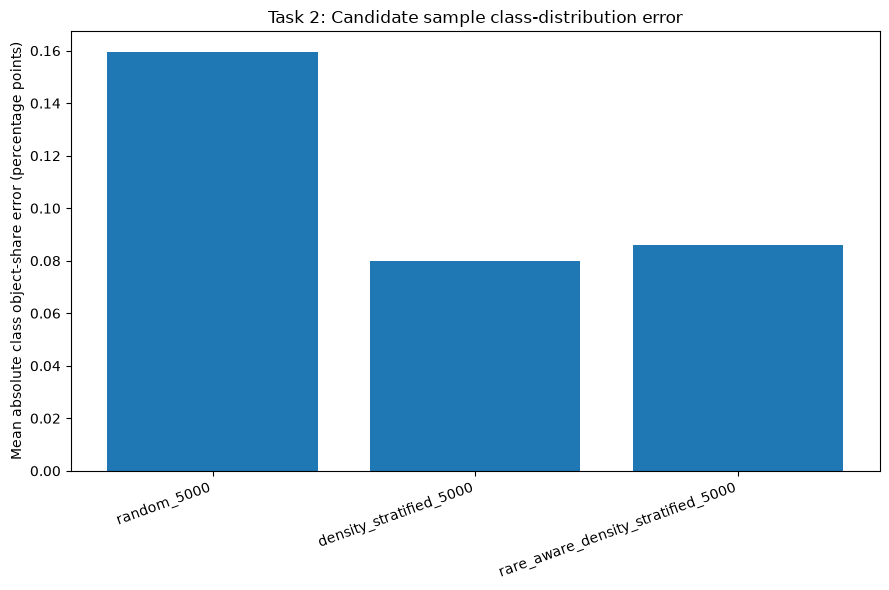

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task2_candidate_class_distribution_error.png')

In [5]:
plt.figure(figsize=(9, 6))
plt.bar(candidate_quality["sample_name"], candidate_quality["class_object_share_mae_pp"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Mean absolute class object-share error (percentage points)")
plt.title("Task 2: Candidate sample class-distribution error")
plt.tight_layout()

figure1_path = FIG / "task2_candidate_class_distribution_error.png"
plt.savefig(figure1_path, dpi=200, bbox_inches="tight")
plt.show()

figure1_path

**Interpretation.** The candidate error figure confirms that random sampling has the largest class-distribution error. The selected rare-aware density-stratified sample remains close to pure density-stratified sampling while providing better rare-class retention. This is why the selected sample is based on a trade-off rather than choosing the lowest class-error value alone.

## Selected Sampling Strategy

The selected sample is `rare_aware_density_stratified_5000`.

The final selected sample was verified to contain:

- 5,000 rows.
- 5,000 unique image files.
- 5,000 unique image paths.
- 0 duplicate images.
- 0 selected images missing from the full dataset index.

This fixed-size subset satisfies the assignment requirement while preserving key dataset structure.

In [6]:
selected_validation = pd.DataFrame([{
    "Selected Rows": len(selected_sample),
    "Unique Image Files": selected_sample["image_file"].nunique(),
    "Unique Image Paths": selected_sample["image_path"].nunique(),
    "Duplicate Image Paths": int(selected_sample.duplicated("image_path").sum()),
    "Total Objects": int(selected_sample["num_objects"].sum()),
    "Mean Objects/Image": round(float(selected_sample["num_objects"].mean()), 3),
    "Images >=10 Objects": int((selected_sample["num_objects"] >= 10).sum()),
    "Images >=20 Objects": int((selected_sample["num_objects"] >= 20).sum()),
}])

selected_validation

,Selected Rows,Unique Image Files,Unique Image Paths,Duplicate Image Paths,Total Objects,Mean Objects/Image,Images >=10 Objects,Images >=20 Objects
0,5000,5000,5000,0,19196,3.839,459,158


## Table 4: Full Dataset vs Selected Sample Summary

This table compares the full dataset with the selected 5,000-image sample at the dataset level.

In [7]:
sample_summary_display = sample_summary.copy()

sample_summary_display = sample_summary_display.rename(columns={
    "dataset": "Dataset",
    "images": "Images",
    "total_objects": "Total Objects",
    "mean_objects_per_image": "Mean Objects/Image",
    "median_objects_per_image": "Median Objects/Image",
    "max_objects_per_image": "Max Objects/Image",
    "images_ge_5_objects": "Images >=5 Objects",
    "images_ge_10_objects": "Images >=10 Objects",
    "images_ge_15_objects": "Images >=15 Objects",
    "images_ge_20_objects": "Images >=20 Objects",
})

sample_summary_display

,Dataset,Images,Total Objects,Mean Objects/Image,Median Objects/Image,Max Objects/Image,Images >=5 Objects,Images >=10 Objects,Images >=15 Objects,Images >=20 Objects
0,full_dataset,9525,36721,3.855,1.0,224,1780,881,517,304
1,rare_aware_density_stratified_5000,5000,19196,3.839,1.0,224,935,459,267,158


**Interpretation.** The selected sample closely preserves the full dataset’s object-density profile. The full dataset has a mean of 3.855 objects per image, while the selected sample has 3.839. The selected sample also keeps the dense-image tail: 459 images have at least 10 objects, and 158 images have at least 20 objects. These values are close to what would be expected from a 5,000-image subset of a 9,525-image dataset.

## Figure 2: Full Dataset vs Selected Sample Class Distribution

This figure compares object-share percentages for each class in the full dataset and selected sample.

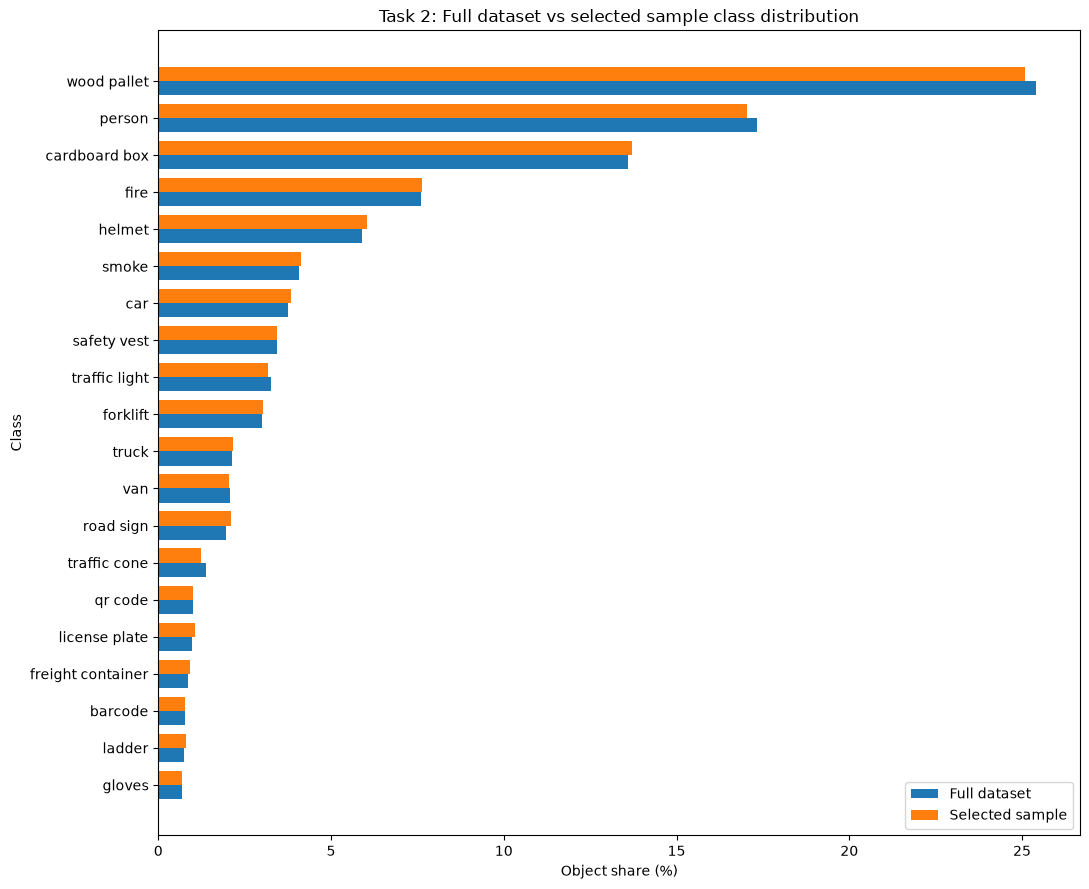

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task2_class_distribution_full_vs_selected_sample.png')

In [8]:
plot_df = class_compare.sort_values("object_count_full", ascending=True).copy()

y = np.arange(len(plot_df))
bar_height = 0.38

plt.figure(figsize=(11, 9))
plt.barh(y - bar_height / 2, plot_df["object_share_pct_full"], height=bar_height, label="Full dataset")
plt.barh(y + bar_height / 2, plot_df["object_share_pct_sample"], height=bar_height, label="Selected sample")

plt.yticks(y, plot_df["class_name"])
plt.xlabel("Object share (%)")
plt.ylabel("Class")
plt.title("Task 2: Full dataset vs selected sample class distribution")
plt.legend()
plt.tight_layout()

figure2_path = FIG / "task2_class_distribution_full_vs_selected_sample.png"
plt.savefig(figure2_path, dpi=200, bbox_inches="tight")
plt.show()

figure2_path

**Interpretation.** The class-distribution figure shows that the selected sample closely follows the full dataset across all 20 classes. The largest object-share differences are small, with wood pallet and person differing by roughly 0.32 and 0.30 percentage points, respectively. This supports using the selected sample as a representative working subset rather than a heavily distorted class-balanced subset.

## Table 5: Largest Class-Distribution Differences

This table isolates the largest object-share differences between the selected sample and the full dataset.

In [9]:
class_diff_display = class_compare.copy()
class_diff_display["abs_object_share_diff_pp"] = class_diff_display["object_share_diff_pp"].abs()

class_diff_display = class_diff_display.sort_values("abs_object_share_diff_pp", ascending=False).head(10)

class_diff_display = class_diff_display.rename(columns={
    "class_name": "Class",
    "object_share_pct_full": "Full Object Share (%)",
    "object_share_pct_sample": "Sample Object Share (%)",
    "object_share_diff_pp": "Object Share Difference (pp)",
    "image_share_pct_full": "Full Image Share (%)",
    "image_share_pct_sample": "Sample Image Share (%)",
    "image_share_diff_pp": "Image Share Difference (pp)",
})

for col in [
    "Full Object Share (%)",
    "Sample Object Share (%)",
    "Object Share Difference (pp)",
    "Full Image Share (%)",
    "Sample Image Share (%)",
    "Image Share Difference (pp)",
]:
    class_diff_display[col] = class_diff_display[col].round(4)

class_diff_display[[
    "Class",
    "Full Object Share (%)",
    "Sample Object Share (%)",
    "Object Share Difference (pp)",
    "Full Image Share (%)",
    "Sample Image Share (%)",
    "Image Share Difference (pp)",
]]

,Class,Full Object Share (%),Sample Object Share (%),Object Share Difference (pp),Full Image Share (%),Sample Image Share (%),Image Share Difference (pp)
19,wood pallet,25.4078,25.0886,-0.3192,7.2336,6.94,-0.2936
10,person,17.3416,17.0452,-0.2964,20.2940,20.32,0.0260
12,road sign,1.9607,2.1150,0.1543,3.9055,3.92,0.0145
7,helmet,5.9094,6.0377,0.1283,6.6247,6.78,0.1553
15,traffic cone,1.3780,1.2503,-0.1277,3.0551,3.08,0.0249
2,cardboard box,13.6026,13.7112,0.1086,4.6509,4.68,0.0291
9,license plate,0.9776,1.0731,0.0955,3.0656,3.20,0.1344
16,traffic light,3.2488,3.1621,-0.0867,9.0919,8.64,-0.4519
1,car,3.7553,3.8393,0.0840,10.4987,11.06,0.5613
14,smoke,4.0712,4.1415,0.0702,10.2362,10.38,0.1438


## Table 6: Rare-Class Coverage

This table verifies that the selected sample met the rare-class retention targets.

In [10]:
rare_display = rare_coverage.copy()

rare_display = rare_display.rename(columns={
    "class_name": "Class",
    "image_count_full": "Full Image Count",
    "image_count_sample": "Sample Image Count",
    "target_image_count": "Target Image Count",
    "sample_image_retention_pct": "Sample Image Retention (%)",
    "object_share_diff_pp": "Object Share Difference (pp)",
    "image_share_diff_pp": "Image Share Difference (pp)",
})

for col in [
    "Sample Image Retention (%)",
    "Object Share Difference (pp)",
    "Image Share Difference (pp)",
]:
    rare_display[col] = rare_display[col].round(4)

rare_display[[
    "Class",
    "Full Image Count",
    "Sample Image Count",
    "Target Image Count",
    "Sample Image Retention (%)",
    "Object Share Difference (pp)",
    "Image Share Difference (pp)",
]]

,Class,Full Image Count,Sample Image Count,Target Image Count,Sample Image Retention (%),Object Share Difference (pp),Image Share Difference (pp)
0,barcode,272,143,143,52.5735,0.0159,0.0044
1,freight container,192,103,101,53.6458,0.0561,0.0443
2,gloves,226,120,119,53.0973,0.0009,0.0273
3,ladder,183,100,100,54.6448,0.0427,0.0787
4,license plate,292,160,154,54.7945,0.0955,0.1344
5,qr code,299,161,157,53.8462,0.0058,0.0809
6,road sign,372,196,196,52.6882,0.1543,0.0145
7,traffic cone,291,154,153,52.9210,-0.1277,0.0249


**Interpretation.** All rare-class targets were met. The minimum rare-class image retention was approximately 52.57%, which matches the overall sample fraction of 5,000 out of 9,525 images. This confirms that the selected sample protects rare classes without forcing a heavily artificial class distribution.

## Figure 3: Full Dataset vs Selected Sample Object-Density Distribution

This figure compares the object-count density distribution between the full dataset and selected sample.

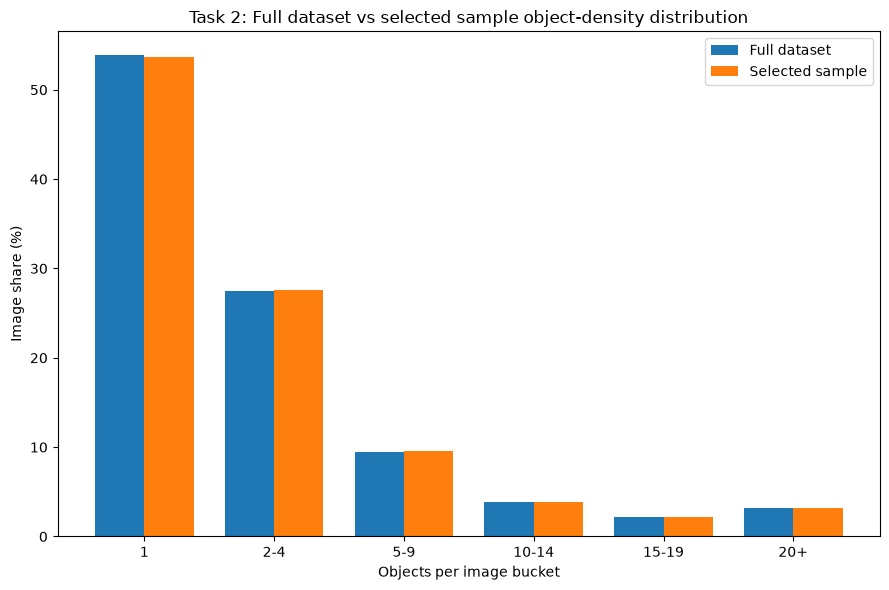

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task2_density_distribution_full_vs_selected_sample.png')

In [11]:
density_plot = density_compare.copy()
x = np.arange(len(density_plot))
bar_width = 0.38

plt.figure(figsize=(9, 6))
plt.bar(x - bar_width / 2, density_plot["image_share_pct_full"], width=bar_width, label="Full dataset")
plt.bar(x + bar_width / 2, density_plot["image_share_pct_sample"], width=bar_width, label="Selected sample")

plt.xticks(x, density_plot["density_bucket"])
plt.xlabel("Objects per image bucket")
plt.ylabel("Image share (%)")
plt.title("Task 2: Full dataset vs selected sample object-density distribution")
plt.legend()
plt.tight_layout()

figure3_path = FIG / "task2_density_distribution_full_vs_selected_sample.png"
plt.savefig(figure3_path, dpi=200, bbox_inches="tight")
plt.show()

figure3_path

**Interpretation.** The object-density distribution is closely preserved. The selected sample keeps nearly the same share of single-object images, medium-density images, and dense images as the full dataset. This is important because later detection and NMS behavior can vary sharply between sparse scenes and dense multi-object scenes.

## Table 7: Object-Density Distribution Comparison

This table gives the exact full-vs-selected image shares for each object-count bucket.

In [12]:
density_display = density_compare.copy()

density_display = density_display.rename(columns={
    "density_bucket": "Objects per Image Bucket",
    "image_count_full": "Full Image Count",
    "image_share_pct_full": "Full Image Share (%)",
    "image_count_sample": "Sample Image Count",
    "image_share_pct_sample": "Sample Image Share (%)",
    "image_share_diff_pp": "Image Share Difference (pp)",
})

for col in ["Full Image Share (%)", "Sample Image Share (%)", "Image Share Difference (pp)"]:
    density_display[col] = density_display[col].round(4)

density_display[[
    "Objects per Image Bucket",
    "Full Image Count",
    "Full Image Share (%)",
    "Sample Image Count",
    "Sample Image Share (%)",
    "Image Share Difference (pp)",
]]

,Objects per Image Bucket,Full Image Count,Full Image Share (%),Sample Image Count,Sample Image Share (%),Image Share Difference (pp)
0,1,5129,53.8478,2686,53.72,-0.1278
1,2-4,2616,27.4646,1379,27.58,0.1154
2,5-9,899,9.4383,476,9.52,0.0817
3,10-14,364,3.8215,192,3.84,0.0185
4,15-19,213,2.2362,109,2.18,-0.0562
5,20+,304,3.1916,158,3.16,-0.0316


## Crowding / Overlap Validation

Object count alone does not fully describe scene difficulty. Twenty objects spread across an image are not the same as twenty objects clustered or overlapping. Since later NMS threshold analysis is sensitive to overlapping boxes, I also validated the selected sample against the full dataset using pairwise ground-truth box IoU.

This is a dataset representativeness check, not a model-evaluation metric. It uses ground-truth box overlap as a proxy for crowded-scene structure before Task 3 examines model-specific prediction behavior.

## Figure 4: Full Dataset vs Selected Sample Crowding Distribution

Crowding buckets are based on the number of ground-truth box pairs in an image with IoU greater than 0.1.

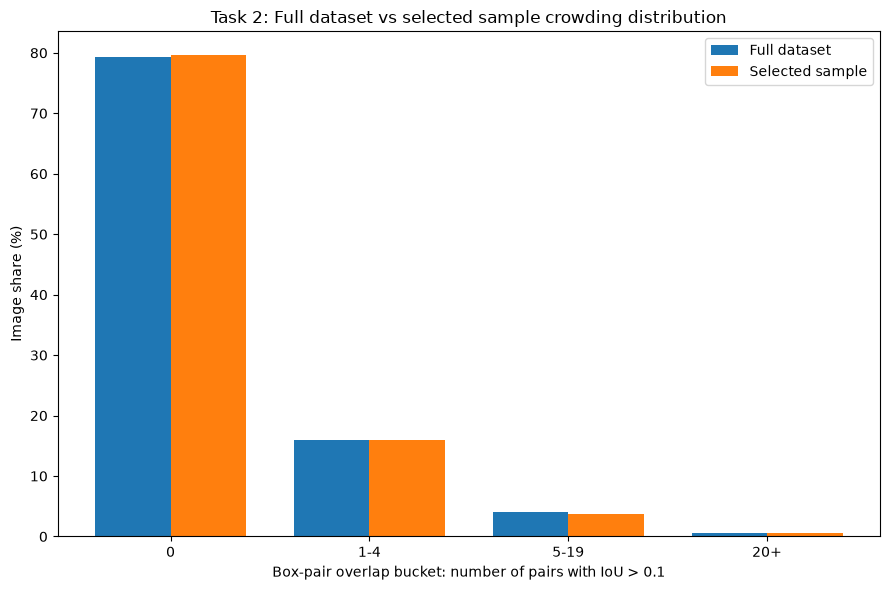

PosixPath('/home/armin/code/techtrack-arminrahbar/analysis/figures/task2_crowding_distribution_full_vs_selected_sample.png')

In [13]:
crowding_plot = crowding_compare.copy()
x = np.arange(len(crowding_plot))
bar_width = 0.38

plt.figure(figsize=(9, 6))
plt.bar(x - bar_width / 2, crowding_plot["image_share_pct_full"], width=bar_width, label="Full dataset")
plt.bar(x + bar_width / 2, crowding_plot["image_share_pct_sample"], width=bar_width, label="Selected sample")

plt.xticks(x, crowding_plot["crowding_bucket"])
plt.xlabel("Box-pair overlap bucket: number of pairs with IoU > 0.1")
plt.ylabel("Image share (%)")
plt.title("Task 2: Full dataset vs selected sample crowding distribution")
plt.legend()
plt.tight_layout()

figure4_path = FIG / "task2_crowding_distribution_full_vs_selected_sample.png"
plt.savefig(figure4_path, dpi=200, bbox_inches="tight")
plt.show()

figure4_path

**Interpretation.** The selected sample closely preserves the full dataset’s crowding distribution. Images with no overlapping ground-truth box pairs are about 79.33% of the full dataset and 79.58% of the selected sample. The most crowded bucket, images with 20 or more overlapping box pairs, is also preserved at a similar share. This supports using the sample for later NMS-related analysis.

## Table 8: Overlap / Crowding Summary

This table compares summary overlap statistics for the full dataset and selected sample.

In [14]:
overlap_display = overlap_summary.copy()

overlap_display = overlap_display.rename(columns={
    "dataset": "Dataset",
    "images": "Images",
    "mean_pair_count": "Mean Box Pairs/Image",
    "mean_max_pairwise_iou": "Mean Max Pairwise IoU",
    "mean_pairs_iou_gt_0_1": "Mean Pairs IoU > 0.1",
    "images_with_any_iou_gt_0_1": "Images with Any IoU > 0.1",
    "images_with_any_iou_gt_0_3": "Images with Any IoU > 0.3",
    "images_with_any_iou_gt_0_5": "Images with Any IoU > 0.5",
    "images_with_20plus_iou_gt_0_1_pairs": "Images with 20+ IoU>0.1 Pairs",
})

overlap_display

,Dataset,Images,Mean Box Pairs/Image,Mean Max Pairwise IoU,Mean Pairs IoU > 0.1,Images with Any IoU > 0.1,Images with Any IoU > 0.3,Images with Any IoU > 0.5,Images with 20+ IoU>0.1 Pairs
0,full_dataset,9525,38.316,0.0760,0.852,1969,932,367,54
1,rare_aware_density_stratified_5000,5000,40.317,0.0756,0.889,1021,486,200,32


## Table 9: Crowding Distribution Comparison

This table gives the exact crowding-bucket counts and shares used in Figure 4.

In [15]:
crowding_display = crowding_compare.copy()

crowding_display = crowding_display.rename(columns={
    "crowding_bucket": "Crowding Bucket",
    "image_count_full": "Full Image Count",
    "image_share_pct_full": "Full Image Share (%)",
    "image_count_sample": "Sample Image Count",
    "image_share_pct_sample": "Sample Image Share (%)",
    "image_share_diff_pp": "Image Share Difference (pp)",
})

for col in ["Full Image Share (%)", "Sample Image Share (%)", "Image Share Difference (pp)"]:
    crowding_display[col] = crowding_display[col].round(4)

crowding_display[[
    "Crowding Bucket",
    "Full Image Count",
    "Full Image Share (%)",
    "Sample Image Count",
    "Sample Image Share (%)",
    "Image Share Difference (pp)",
]]

,Crowding Bucket,Full Image Count,Full Image Share (%),Sample Image Count,Sample Image Share (%),Image Share Difference (pp)
0,0,7556,79.3281,3979,79.58,0.2519
1,1-4,1528,16.0420,802,16.04,-0.0020
2,5-19,387,4.0630,187,3.74,-0.3230
3,20+,54,0.5669,32,0.64,0.0731


## Task 2 Conclusion

The selected `rare_aware_density_stratified_5000` sample is a defensible working subset for the remaining TechTrack analysis tasks. It satisfies the minimum 5,000-image requirement and preserves the full dataset across the major dimensions that matter for object detection:

- Class distribution remains close to the full dataset.
- Rare-class targets are met.
- Object-density distribution is preserved.
- Dense-image coverage remains close to proportional.
- Ground-truth crowding / overlap distribution is preserved, which supports later NMS analysis.

The selected subset should be treated as a representative working sample for compute-heavy experimentation, not as a permanent replacement for full-dataset validation when full validation is feasible.

## Appendix A: Full Task 2 Pipeline Code

This appendix records the scripts used to generate the Task 2 CSV outputs and figures. The notebook above loads the verified outputs from these scripts and presents the tables and figures used in the case analysis.


### `analysis/task2_build_dataset_index.py`

```python
from pathlib import Path
import csv
import json
import re
from collections import Counter

ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "techtrack" / "storage" / "logistics"
NAMES_FILE = ROOT / "techtrack" / "storage" / "yolo_model_1" / "logistics.names"
OUT_DIR = ROOT / "analysis" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

classes = [line.strip() for line in NAMES_FILE.read_text().splitlines() if line.strip()]

def clean_col(name: str) -> str:
    name = name.lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return name.strip("_")

class_cols = [f"count_{clean_col(c)}" for c in classes]

image_paths = sorted(DATA_DIR.glob("*.jpg"))

rows = []
object_counter = Counter()
image_counter = Counter()
object_count_distribution = Counter()
missing_labels = []

for image_path in image_paths:
    label_path = image_path.with_suffix(".txt")

    if not label_path.exists():
        missing_labels.append(str(image_path))
        continue

    class_counts = Counter()
    total_objects = 0

    label_text = label_path.read_text().strip()
    if label_text:
        for line in label_text.splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            class_id = int(float(parts[0]))
            if 0 <= class_id < len(classes):
                class_counts[class_id] += 1
                object_counter[class_id] += 1
                total_objects += 1

    for class_id in class_counts:
        image_counter[class_id] += 1

    object_count_distribution[total_objects] += 1

    row = {
        "image_path": str(image_path.relative_to(ROOT)),
        "label_path": str(label_path.relative_to(ROOT)),
        "image_file": image_path.name,
        "label_file": label_path.name,
        "num_objects": total_objects,
        "class_ids_present": json.dumps(sorted(class_counts.keys())),
        "class_names_present": json.dumps([classes[i] for i in sorted(class_counts.keys())]),
    }

    for class_id, col in enumerate(class_cols):
        row[col] = class_counts.get(class_id, 0)

    rows.append(row)

if not rows:
    raise RuntimeError(f"No image-label pairs were indexed from {DATA_DIR}")

dataset_index_path = OUT_DIR / "task2_dataset_index.csv"
with dataset_index_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

class_summary_path = OUT_DIR / "task2_class_distribution_full.csv"
with class_summary_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["class_id", "class_name", "object_count", "image_count"])
    writer.writeheader()
    for class_id, class_name in enumerate(classes):
        writer.writerow({
            "class_id": class_id,
            "class_name": class_name,
            "object_count": object_counter[class_id],
            "image_count": image_counter[class_id],
        })

object_dist_path = OUT_DIR / "task2_object_count_distribution_full.csv"
with object_dist_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["num_objects", "image_count"])
    writer.writeheader()
    for num_objects, image_count in sorted(object_count_distribution.items()):
        writer.writerow({
            "num_objects": num_objects,
            "image_count": image_count,
        })

print("Dataset index written:", dataset_index_path)
print("Class distribution written:", class_summary_path)
print("Object-count distribution written:", object_dist_path)
print("Images indexed:", len(rows))
print("Missing labels:", len(missing_labels))
print("Total labeled objects:", sum(object_counter.values()))
```

### `analysis/task2_summarize_dataset.py`

```python
import pandas as pd
from pathlib import Path

out = Path("analysis/outputs")
out.mkdir(parents=True, exist_ok=True)

idx = pd.read_csv(out / "task2_dataset_index.csv")
cls = pd.read_csv(out / "task2_class_distribution_full.csv")
obj = pd.read_csv(out / "task2_object_count_distribution_full.csv")

summary = pd.DataFrame([{
    "dataset": "full_dataset",
    "images": len(idx),
    "total_objects": int(cls["object_count"].sum()),
    "images_with_zero_objects": int((idx["num_objects"] == 0).sum()),
    "mean_objects_per_image": round(idx["num_objects"].mean(), 3),
    "median_objects_per_image": idx["num_objects"].median(),
    "max_objects_per_image": int(idx["num_objects"].max()),
    "images_ge_5_objects": int((idx["num_objects"] >= 5).sum()),
    "images_ge_10_objects": int((idx["num_objects"] >= 10).sum()),
    "images_ge_15_objects": int((idx["num_objects"] >= 15).sum()),
    "images_ge_20_objects": int((idx["num_objects"] >= 20).sum()),
}])

summary_path = out / "task2_full_dataset_summary.csv"
summary.to_csv(summary_path, index=False)

cls_enriched = cls.copy()
total_objects = cls_enriched["object_count"].sum()
total_images = len(idx)

cls_enriched["object_share_pct"] = (100 * cls_enriched["object_count"] / total_objects).round(4)
cls_enriched["image_share_pct"] = (100 * cls_enriched["image_count"] / total_images).round(4)

cls_enriched_path = out / "task2_class_distribution_full_enriched.csv"
cls_enriched.to_csv(cls_enriched_path, index=False)

top_classes = cls_enriched.sort_values("object_count", ascending=False).head(10)
bottom_classes = cls_enriched.sort_values("object_count", ascending=True).head(10)

top_path = out / "task2_top10_classes_by_object_count.csv"
bottom_path = out / "task2_bottom10_classes_by_object_count.csv"

top_classes.to_csv(top_path, index=False)
bottom_classes.to_csv(bottom_path, index=False)

def density_bucket(n: int) -> str:
    if n <= 1:
        return "1"
    if n <= 4:
        return "2-4"
    if n <= 9:
        return "5-9"
    if n <= 14:
        return "10-14"
    if n <= 19:
        return "15-19"
    return "20+"

idx_with_density = idx.copy()
idx_with_density["density_bucket"] = idx_with_density["num_objects"].apply(density_bucket)

bucket_order = ["1", "2-4", "5-9", "10-14", "15-19", "20+"]
density_summary = (
    idx_with_density["density_bucket"]
    .value_counts()
    .reindex(bucket_order, fill_value=0)
    .rename_axis("density_bucket")
    .reset_index(name="image_count")
)

density_summary["image_share_pct"] = (100 * density_summary["image_count"] / len(idx)).round(4)

density_path = out / "task2_density_bucket_distribution_full.csv"
density_summary.to_csv(density_path, index=False)

dense_counts = pd.DataFrame([
    {"threshold": ">=5 objects", "image_count": int((idx["num_objects"] >= 5).sum())},
    {"threshold": ">=10 objects", "image_count": int((idx["num_objects"] >= 10).sum())},
    {"threshold": ">=15 objects", "image_count": int((idx["num_objects"] >= 15).sum())},
    {"threshold": ">=20 objects", "image_count": int((idx["num_objects"] >= 20).sum())},
])

dense_counts["image_share_pct"] = (100 * dense_counts["image_count"] / len(idx)).round(4)

dense_path = out / "task2_dense_image_counts_full.csv"
dense_counts.to_csv(dense_path, index=False)

print("DATASET SUMMARY")
print("---------------")
print(summary.to_string(index=False))

print("\nTOP 10 CLASSES BY OBJECT COUNT")
print(top_classes.to_string(index=False))

print("\nBOTTOM 10 CLASSES BY OBJECT COUNT")
print(bottom_classes.to_string(index=False))

print("\nDENSITY BUCKET DISTRIBUTION")
print(density_summary.to_string(index=False))

print("\nDENSE IMAGE COUNTS")
print(dense_counts.to_string(index=False))

print("\nWrote:")
print(summary_path)
print(cls_enriched_path)
print(top_path)
print(bottom_path)
print(density_path)
print(dense_path)

```

### `analysis/task2_sampling_strategy.py`

```python
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1]
OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZE = 5000
RANDOM_SEED = 42


def clean_col(name: str) -> str:
    name = name.lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return name.strip("_")


def density_bucket(n: int) -> str:
    if n <= 1:
        return "1"
    if n <= 4:
        return "2-4"
    if n <= 9:
        return "5-9"
    if n <= 14:
        return "10-14"
    if n <= 19:
        return "15-19"
    return "20+"


def proportional_sample(df: pd.DataFrame, group_col: str, n: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    group_counts = df[group_col].value_counts().sort_index()
    raw_targets = group_counts / len(df) * n
    targets = np.floor(raw_targets).astype(int)

    remainder = n - int(targets.sum())
    if remainder > 0:
        add_order = (raw_targets - targets).sort_values(ascending=False).index.tolist()
        for group in add_order[:remainder]:
            targets[group] += 1

    sampled = []
    for group, group_n in targets.items():
        group_df = df[df[group_col] == group]
        group_n = min(int(group_n), len(group_df))
        if group_n > 0:
            sampled.append(group_df.sample(n=group_n, random_state=int(rng.integers(0, 1_000_000))))

    sample = pd.concat(sampled, axis=0)

    if len(sample) < n:
        remaining = df.drop(index=sample.index)
        fill_n = min(n - len(sample), len(remaining))
        sample = pd.concat([
            sample,
            remaining.sample(n=fill_n, random_state=int(rng.integers(0, 1_000_000)))
        ])

    if len(sample) > n:
        sample = sample.sample(n=n, random_state=seed)

    return sample


def class_distribution(df: pd.DataFrame, cls: pd.DataFrame, label: str) -> pd.DataFrame:
    total_objects = int(df["num_objects"].sum())
    total_images = len(df)
    rows = []

    for _, row in cls.iterrows():
        class_name = row["class_name"]
        col = f"count_{clean_col(class_name)}"

        object_count = int(df[col].sum())
        image_count = int((df[col] > 0).sum())

        rows.append({
            "dataset": label,
            "class_id": int(row["class_id"]),
            "class_name": class_name,
            "object_count": object_count,
            "image_count": image_count,
            "object_share_pct": 100 * object_count / total_objects if total_objects else 0,
            "image_share_pct": 100 * image_count / total_images if total_images else 0,
        })

    return pd.DataFrame(rows)


def density_distribution(df: pd.DataFrame, label: str) -> pd.DataFrame:
    bucket_order = ["1", "2-4", "5-9", "10-14", "15-19", "20+"]
    counts = df["density_bucket"].value_counts().reindex(bucket_order, fill_value=0)

    return pd.DataFrame({
        "dataset": label,
        "density_bucket": bucket_order,
        "image_count": counts.values,
        "image_share_pct": 100 * counts.values / len(df),
    })


def dataset_summary(df: pd.DataFrame, label: str) -> dict:
    return {
        "dataset": label,
        "images": int(len(df)),
        "total_objects": int(df["num_objects"].sum()),
        "mean_objects_per_image": round(float(df["num_objects"].mean()), 3),
        "median_objects_per_image": float(df["num_objects"].median()),
        "max_objects_per_image": int(df["num_objects"].max()),
        "images_ge_5_objects": int((df["num_objects"] >= 5).sum()),
        "images_ge_10_objects": int((df["num_objects"] >= 10).sum()),
        "images_ge_15_objects": int((df["num_objects"] >= 15).sum()),
        "images_ge_20_objects": int((df["num_objects"] >= 20).sum()),
    }


def rare_class_targets(cls: pd.DataFrame, sample_fraction: float) -> pd.DataFrame:
    rare = cls.sort_values("object_count", ascending=True).head(8).copy()

    # Target is roughly proportional to the sample size, with a small floor.
    # This protects rare classes without forcing 100% retention or badly distorting the distribution.
    rare["target_image_count"] = rare["image_count"].apply(
        lambda x: min(int(x), max(int(np.ceil(x * sample_fraction)), min(100, int(x))))
    )

    return rare


def enforce_rare_class_targets(
    base_sample: pd.DataFrame,
    full_df: pd.DataFrame,
    rare_targets: pd.DataFrame,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    sample = base_sample.copy()

    for _, row in rare_targets.iterrows():
        class_name = row["class_name"]
        target = int(row["target_image_count"])
        col = f"count_{clean_col(class_name)}"

        current = int((sample[col] > 0).sum())
        needed = target - current

        if needed <= 0:
            continue

        selected_paths = set(sample["image_path"])
        outside = full_df[~full_df["image_path"].isin(selected_paths)]
        candidates = outside[outside[col] > 0]

        if len(candidates) == 0:
            continue

        add_n = min(needed, len(candidates))
        additions = candidates.sample(n=add_n, random_state=int(rng.integers(0, 1_000_000)))
        sample = pd.concat([sample, additions], axis=0)

    sample = sample.drop_duplicates(subset=["image_path"], keep="first").copy()

    # Trim back to SAMPLE_SIZE by removing non-rare images first.
    if len(sample) > SAMPLE_SIZE:
        rare_cols = [f"count_{clean_col(c)}" for c in rare_targets["class_name"].tolist()]
        sample = sample.copy()
        sample["_rare_object_count"] = sample[rare_cols].sum(axis=1)

        excess = len(sample) - SAMPLE_SIZE
        removable = sample[sample["_rare_object_count"] == 0]

        if len(removable) >= excess:
            remove_idx = removable.sample(n=excess, random_state=seed).index
            sample = sample.drop(index=remove_idx)
        else:
            sample = sample.drop(index=removable.index)
            excess = len(sample) - SAMPLE_SIZE
            if excess > 0:
                remove_idx = sample.sample(n=excess, random_state=seed).index
                sample = sample.drop(index=remove_idx)

        sample = sample.drop(columns=["_rare_object_count"], errors="ignore")

    # Fill if short, using only unused images.
    if len(sample) < SAMPLE_SIZE:
        selected_paths = set(sample["image_path"])
        remaining = full_df[~full_df["image_path"].isin(selected_paths)]
        fill = remaining.sample(n=SAMPLE_SIZE - len(sample), random_state=seed)
        sample = pd.concat([sample, fill], axis=0)

    sample = sample.drop_duplicates(subset=["image_path"], keep="first").copy()

    if len(sample) != SAMPLE_SIZE:
        raise ValueError(f"Expected {SAMPLE_SIZE} unique images, got {len(sample)}")

    if sample["image_path"].nunique() != SAMPLE_SIZE:
        raise ValueError("Duplicate image_path values remain in selected sample.")

    return sample.sort_values("image_file").reset_index(drop=True)


def compare_sample(full_df: pd.DataFrame, sample_df: pd.DataFrame, cls: pd.DataFrame, name: str, rare_targets: pd.DataFrame) -> dict:
    full_class = class_distribution(full_df, cls, "full")
    sample_class = class_distribution(sample_df, cls, name)

    class_cmp = full_class.merge(
        sample_class,
        on=["class_id", "class_name"],
        suffixes=("_full", "_sample")
    )

    class_cmp["object_share_abs_error_pp"] = (
        class_cmp["object_share_pct_sample"] - class_cmp["object_share_pct_full"]
    ).abs()

    full_density = density_distribution(full_df, "full")
    sample_density = density_distribution(sample_df, name)

    density_cmp = full_density.merge(
        sample_density,
        on="density_bucket",
        suffixes=("_full", "_sample")
    )

    density_cmp["image_share_abs_error_pp"] = (
        density_cmp["image_share_pct_sample"] - density_cmp["image_share_pct_full"]
    ).abs()

    rare_cmp = class_cmp[class_cmp["class_name"].isin(rare_targets["class_name"])].copy()
    rare_cmp["rare_image_retention_pct"] = (
        100 * rare_cmp["image_count_sample"] / rare_cmp["image_count_full"]
    )

    return {
        "sample_name": name,
        "images": int(len(sample_df)),
        "total_objects": int(sample_df["num_objects"].sum()),
        "mean_objects_per_image": round(float(sample_df["num_objects"].mean()), 3),
        "class_object_share_mae_pp": round(float(class_cmp["object_share_abs_error_pp"].mean()), 4),
        "class_object_share_max_error_pp": round(float(class_cmp["object_share_abs_error_pp"].max()), 4),
        "density_share_mae_pp": round(float(density_cmp["image_share_abs_error_pp"].mean()), 4),
        "density_share_max_error_pp": round(float(density_cmp["image_share_abs_error_pp"].max()), 4),
        "min_rare_class_image_retention_pct": round(float(rare_cmp["rare_image_retention_pct"].min()), 2),
        "images_ge_10_objects": int((sample_df["num_objects"] >= 10).sum()),
        "images_ge_20_objects": int((sample_df["num_objects"] >= 20).sum()),
    }


def main():
    idx = pd.read_csv(OUT / "task2_dataset_index.csv")
    cls = pd.read_csv(OUT / "task2_class_distribution_full.csv")

    idx["density_bucket"] = idx["num_objects"].apply(density_bucket)

    sample_fraction = SAMPLE_SIZE / len(idx)
    rare_targets = rare_class_targets(cls, sample_fraction)
    rare_targets.to_csv(OUT / "task2_rare_class_targets.csv", index=False)

    random_sample = idx.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
    density_sample = proportional_sample(idx, "density_bucket", SAMPLE_SIZE, RANDOM_SEED)

    rare_density_sample = enforce_rare_class_targets(
        base_sample=density_sample,
        full_df=idx,
        rare_targets=rare_targets,
        seed=RANDOM_SEED,
    )

    candidates = {
        "random_5000": random_sample,
        "density_stratified_5000": density_sample,
        "rare_aware_density_stratified_5000": rare_density_sample,
    }

    quality = pd.DataFrame([
        compare_sample(idx, sample, cls, name, rare_targets)
        for name, sample in candidates.items()
    ])

    quality.to_csv(OUT / "task2_candidate_sample_quality.csv", index=False)

    selected_name = "rare_aware_density_stratified_5000"
    selected = candidates[selected_name].copy()
    selected.to_csv(OUT / "task2_selected_sample_index.csv", index=False)

    summary = pd.DataFrame([
        dataset_summary(idx, "full_dataset"),
        dataset_summary(selected, selected_name),
    ])
    summary.to_csv(OUT / "task2_full_vs_selected_sample_summary.csv", index=False)

    full_class = class_distribution(idx, cls, "full_dataset")
    selected_class = class_distribution(selected, cls, selected_name)

    class_compare = full_class.merge(
        selected_class,
        on=["class_id", "class_name"],
        suffixes=("_full", "_sample")
    )

    class_compare["object_share_diff_pp"] = (
        class_compare["object_share_pct_sample"] - class_compare["object_share_pct_full"]
    )
    class_compare["image_share_diff_pp"] = (
        class_compare["image_share_pct_sample"] - class_compare["image_share_pct_full"]
    )

    class_compare.to_csv(OUT / "task2_full_vs_selected_class_distribution.csv", index=False)

    rare_coverage = class_compare[class_compare["class_name"].isin(rare_targets["class_name"])].copy()
    rare_coverage = rare_coverage.merge(
        rare_targets[["class_name", "target_image_count"]],
        on="class_name",
        how="left"
    )
    rare_coverage["sample_image_retention_pct"] = (
        100 * rare_coverage["image_count_sample"] / rare_coverage["image_count_full"]
    )

    rare_coverage.to_csv(OUT / "task2_selected_rare_class_coverage.csv", index=False)

    full_density = density_distribution(idx, "full_dataset")
    selected_density = density_distribution(selected, selected_name)

    density_compare = full_density.merge(
        selected_density,
        on="density_bucket",
        suffixes=("_full", "_sample")
    )
    density_compare["image_share_diff_pp"] = (
        density_compare["image_share_pct_sample"] - density_compare["image_share_pct_full"]
    )

    density_compare.to_csv(OUT / "task2_full_vs_selected_density_distribution.csv", index=False)

    # Figure 1: class distribution full vs selected.
    plot_df = class_compare.sort_values("object_count_full", ascending=True)
    y = np.arange(len(plot_df))
    bar_height = 0.38

    plt.figure(figsize=(11, 9))
    plt.barh(y - bar_height / 2, plot_df["object_share_pct_full"], height=bar_height, label="Full dataset")
    plt.barh(y + bar_height / 2, plot_df["object_share_pct_sample"], height=bar_height, label="Selected sample")
    plt.yticks(y, plot_df["class_name"])
    plt.xlabel("Object share (%)")
    plt.ylabel("Class")
    plt.title("Task 2: Full dataset vs selected sample class distribution")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG / "task2_class_distribution_full_vs_selected_sample.png", dpi=200, bbox_inches="tight")
    plt.close()

    # Figure 2: density distribution full vs selected.
    density_plot = density_compare.copy()
    x = np.arange(len(density_plot))
    bar_width = 0.38

    plt.figure(figsize=(9, 6))
    plt.bar(x - bar_width / 2, density_plot["image_share_pct_full"], width=bar_width, label="Full dataset")
    plt.bar(x + bar_width / 2, density_plot["image_share_pct_sample"], width=bar_width, label="Selected sample")
    plt.xticks(x, density_plot["density_bucket"])
    plt.xlabel("Objects per image bucket")
    plt.ylabel("Image share (%)")
    plt.title("Task 2: Full dataset vs selected sample object-density distribution")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG / "task2_density_distribution_full_vs_selected_sample.png", dpi=200, bbox_inches="tight")
    plt.close()

    # Figure 3: candidate quality by class-distribution error.
    plt.figure(figsize=(9, 6))
    plt.bar(quality["sample_name"], quality["class_object_share_mae_pp"])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Mean absolute class object-share error (percentage points)")
    plt.title("Task 2: Candidate sample class-distribution error")
    plt.tight_layout()
    plt.savefig(FIG / "task2_candidate_class_distribution_error.png", dpi=200, bbox_inches="tight")
    plt.close()

    print("Rare-class targets:")
    print(rare_targets.to_string(index=False))

    print("\nCandidate sample quality:")
    print(quality.to_string(index=False))

    print("\nSelected sample:", selected_name)
    print("Selected sample images:", len(selected))

    print("\nWrote:")
    print(OUT / "task2_rare_class_targets.csv")
    print(OUT / "task2_candidate_sample_quality.csv")
    print(OUT / "task2_selected_sample_index.csv")
    print(OUT / "task2_full_vs_selected_sample_summary.csv")
    print(OUT / "task2_full_vs_selected_class_distribution.csv")
    print(OUT / "task2_selected_rare_class_coverage.csv")
    print(OUT / "task2_full_vs_selected_density_distribution.csv")
    print(FIG / "task2_class_distribution_full_vs_selected_sample.png")
    print(FIG / "task2_density_distribution_full_vs_selected_sample.png")
    print(FIG / "task2_candidate_class_distribution_error.png")


if __name__ == "__main__":
    main()

```

### `analysis/task2_overlap_analysis.py`

```python
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(ROOT))

from techtrack.modules.utils.metrics import calculate_iou

OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"
FIG.mkdir(parents=True, exist_ok=True)


def yolo_to_xywh(cx, cy, w, h):
    """
    Convert YOLO normalized center-format boxes into top-left xywh format.
    This matches the box format used by metrics.py in the Task 1 evaluation pipeline.
    """
    x = cx - w / 2
    y = cy - h / 2
    return [x, y, w, h]


def crowding_bucket(pairs_gt_01):
    if pairs_gt_01 == 0:
        return "0"
    if pairs_gt_01 <= 4:
        return "1-4"
    if pairs_gt_01 <= 19:
        return "5-19"
    return "20+"


def compute_overlap_for_label(label_path):
    text = label_path.read_text().strip()
    boxes = []

    if text:
        for line in text.splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            cx = float(parts[1])
            cy = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])

            boxes.append(yolo_to_xywh(cx, cy, w, h))

    n = len(boxes)

    if n < 2:
        return {
            "pair_count": 0,
            "max_pairwise_iou": 0.0,
            "mean_pairwise_iou": 0.0,
            "pairs_iou_gt_0_1": 0,
            "pairs_iou_gt_0_3": 0,
            "pairs_iou_gt_0_5": 0,
        }

    ious = []

    for i in range(n):
        for j in range(i + 1, n):
            iou = float(calculate_iou(boxes[i], boxes[j]))
            iou = min(1.0, max(0.0, iou))
            ious.append(iou)

    ious = np.array(ious)

    return {
        "pair_count": int(len(ious)),
        "max_pairwise_iou": float(ious.max()) if len(ious) else 0.0,
        "mean_pairwise_iou": float(ious.mean()) if len(ious) else 0.0,
        "pairs_iou_gt_0_1": int((ious > 0.1).sum()),
        "pairs_iou_gt_0_3": int((ious > 0.3).sum()),
        "pairs_iou_gt_0_5": int((ious > 0.5).sum()),
    }


def summarize_overlap(df, label):
    return {
        "dataset": label,
        "images": int(len(df)),
        "mean_pair_count": round(float(df["pair_count"].mean()), 3),
        "mean_max_pairwise_iou": round(float(df["max_pairwise_iou"].mean()), 4),
        "mean_pairs_iou_gt_0_1": round(float(df["pairs_iou_gt_0_1"].mean()), 3),
        "images_with_any_iou_gt_0_1": int((df["pairs_iou_gt_0_1"] > 0).sum()),
        "images_with_any_iou_gt_0_3": int((df["pairs_iou_gt_0_3"] > 0).sum()),
        "images_with_any_iou_gt_0_5": int((df["pairs_iou_gt_0_5"] > 0).sum()),
        "images_with_20plus_iou_gt_0_1_pairs": int((df["pairs_iou_gt_0_1"] >= 20).sum()),
    }


def crowding_distribution(df, label):
    order = ["0", "1-4", "5-19", "20+"]
    counts = df["crowding_bucket"].value_counts().reindex(order, fill_value=0)

    return pd.DataFrame({
        "dataset": label,
        "crowding_bucket": order,
        "image_count": counts.values,
        "image_share_pct": 100 * counts.values / len(df),
    })


def main():
    idx = pd.read_csv(OUT / "task2_dataset_index.csv")
    selected = pd.read_csv(OUT / "task2_selected_sample_index.csv")

    rows = []

    for row_num, row in idx.iterrows():
        label_path = ROOT / row["label_path"]
        metrics = compute_overlap_for_label(label_path)

        rows.append({
            "image_file": row["image_file"],
            "image_path": row["image_path"],
            "label_path": row["label_path"],
            "num_objects": int(row["num_objects"]),
            **metrics,
        })

        if (row_num + 1) % 1000 == 0:
            print(f"Processed {row_num + 1}/{len(idx)} images")

    overlap = pd.DataFrame(rows)
    overlap["crowding_bucket"] = overlap["pairs_iou_gt_0_1"].apply(crowding_bucket)

    overlap_path = OUT / "task2_image_overlap_profile.csv"
    overlap.to_csv(overlap_path, index=False)

    selected_files = set(selected["image_file"])
    selected_overlap = overlap[overlap["image_file"].isin(selected_files)].copy()

    summary = pd.DataFrame([
        summarize_overlap(overlap, "full_dataset"),
        summarize_overlap(selected_overlap, "rare_aware_density_stratified_5000"),
    ])

    summary_path = OUT / "task2_full_vs_selected_overlap_summary.csv"
    summary.to_csv(summary_path, index=False)

    full_crowding = crowding_distribution(overlap, "full_dataset")
    selected_crowding = crowding_distribution(selected_overlap, "rare_aware_density_stratified_5000")

    crowding_compare = full_crowding.merge(
        selected_crowding,
        on="crowding_bucket",
        suffixes=("_full", "_sample"),
    )

    crowding_compare["image_share_diff_pp"] = (
        crowding_compare["image_share_pct_sample"] - crowding_compare["image_share_pct_full"]
    )

    crowding_path = OUT / "task2_full_vs_selected_crowding_distribution.csv"
    crowding_compare.to_csv(crowding_path, index=False)

    x = np.arange(len(crowding_compare))
    width = 0.38

    plt.figure(figsize=(9, 6))
    plt.bar(x - width / 2, crowding_compare["image_share_pct_full"], width=width, label="Full dataset")
    plt.bar(x + width / 2, crowding_compare["image_share_pct_sample"], width=width, label="Selected sample")
    plt.xticks(x, crowding_compare["crowding_bucket"])
    plt.xlabel("Box-pair overlap bucket: number of pairs with IoU > 0.1")
    plt.ylabel("Image share (%)")
    plt.title("Task 2: Full dataset vs selected sample crowding distribution")
    plt.legend()
    plt.tight_layout()

    figure_path = FIG / "task2_crowding_distribution_full_vs_selected_sample.png"
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.close()

    print()
    print("OVERLAP SUMMARY")
    print(summary.to_string(index=False))

    print()
    print("CROWDING DISTRIBUTION")
    print(crowding_compare.to_string(index=False))

    print()
    print("Wrote:")
    print(overlap_path)
    print(summary_path)
    print(crowding_path)
    print(figure_path)


if __name__ == "__main__":
    main()

```